# Assess Correct Sample Ordering via Correlations

## Purpose: 

* Check that the sample ordering is correct in that it should be "KD-1", "KD-2", "CTRL-1", "CTRL-2"
    * We are only checking that the correlation between samples of the same condition is higher than between different conditions. 
    * Not possible to confirm it is KD and then CTRL instead of CTRL and then KD. 
    
* This came about due to me discovering the following bug: 
    * https://github.com/NNeuralDynamics/as-rmats-turbo-encode/issues/2

In [1]:
from IPython.core.interactiveshell import InteractiveShell
InteractiveShell.ast_node_interactivity = "all"

import pandas as pd
pd.set_option('display.max_rows', 1000000)
pd.set_option('display.max_columns', 1000000)
pd.set_option('display.max_colwidth', 10000000)

from pathlib import Path
import itertools
import seaborn as sns
import matplotlib.pyplot as plt

import polars as pl 
_=pl.Config.set_tbl_cols(100000)
_=pl.Config.set_tbl_rows(10000)
_=pl.Config.set_tbl_width_chars(10000)
_=pl.Config.set_fmt_str_lengths(10000)


## Load all SE Files

In [2]:
# Define the directory to search
base_dir = Path("/project/PlatigLab/data/collaborators/BWH/1_ENCODE_shRNA_RBP_KD_2024-04-hg38-gencode-v29/")

# Recursively glob for "SE.MATS.JC.txt" files
files = list(base_dir.rglob("SE.MATS.JC.txt"))

# Filter out paths that contain "transfection"
filtered_files = sorted([file for file in files if "transfection" not in str(file).lower()])

filtered_files

[PosixPath('/project/PlatigLab/data/collaborators/BWH/1_ENCODE_shRNA_RBP_KD_2024-04-hg38-gencode-v29/AARS-BGHLV17-HepG2/SE.MATS.JC.txt'),
 PosixPath('/project/PlatigLab/data/collaborators/BWH/1_ENCODE_shRNA_RBP_KD_2024-04-hg38-gencode-v29/AARS-BGKLV21-K562/SE.MATS.JC.txt'),
 PosixPath('/project/PlatigLab/data/collaborators/BWH/1_ENCODE_shRNA_RBP_KD_2024-04-hg38-gencode-v29/AATF-BGHLV14-HepG2/SE.MATS.JC.txt'),
 PosixPath('/project/PlatigLab/data/collaborators/BWH/1_ENCODE_shRNA_RBP_KD_2024-04-hg38-gencode-v29/AATF-BGKLV13-K562/SE.MATS.JC.txt'),
 PosixPath('/project/PlatigLab/data/collaborators/BWH/1_ENCODE_shRNA_RBP_KD_2024-04-hg38-gencode-v29/ABCF1-BGHLV30-HepG2/SE.MATS.JC.txt'),
 PosixPath('/project/PlatigLab/data/collaborators/BWH/1_ENCODE_shRNA_RBP_KD_2024-04-hg38-gencode-v29/ABCF1-BGKLV29-K562/SE.MATS.JC.txt'),
 PosixPath('/project/PlatigLab/data/collaborators/BWH/1_ENCODE_shRNA_RBP_KD_2024-04-hg38-gencode-v29/ABT1-BGHLV37-HepG2/SE.MATS.JC.txt'),
 PosixPath('/project/PlatigLab/data

## Load PSI values for rows where all 4 PSI values are available (no `NA`'s)

In [3]:
dataframes = []

for file in filtered_files:
    # Extract sample_id and split it into components
    sample_id = file.parts[-2]
    assert len(sample_id.split("-")) ==3
    rbp, batch, cell_line = sample_id.split("-")[:3]
    
    # Read and process the file
    df = (
        pl.scan_csv(file, separator="\t")
        .select(["IncLevel1", "IncLevel2"])
        .filter(~pl.col("IncLevel1").str.contains("NA") & ~pl.col("IncLevel2").str.contains("NA"))
        .collect()
        .to_pandas()
    )
    
    # Add new columns for cell line, batch, and RBP
    df['Cell Line'] = cell_line
    df['Batch'] = batch
    df['RBP'] = rbp
    
    # Append the processed dataframe to the list
    dataframes.append(df)

In [4]:

for df in dataframes:
    df[[1, 2]] = df['IncLevel1'].str.split(',', expand=True)
    df[[3, 4]] = df['IncLevel2'].str.split(',', expand=True)

    df[[1, 2, 3, 4]] = df[[1, 2, 3, 4]].astype('float64')


## Calculate correlation between same condition and different condition columns

In [5]:

correlation_results = []

for df in dataframes:
    for (col1, col2), condition in [((1, 2), "Same Condition"), ((3, 4), "Same Condition"), 
                                    ((1, 3), "Different Condition"), ((2, 4), "Different Condition")]:
        pearson_corr = df[col1].corr(df[col2], method='pearson')
        spearman_corr = df[col1].corr(df[col2], method='spearman')
        
        correlation_results.append({
            'Column1': col1,
            'Column2': col2,
            'Condition Status': condition,
            'Pearson Correlation': pearson_corr,
            'Spearman Correlation': spearman_corr,
            'Cell Line': df['Cell Line'].iloc[0],
            'Batch': df['Batch'].iloc[0],
            'RBP': df['RBP'].iloc[0]
        })
        
correlation_df = pd.DataFrame(correlation_results)


In [6]:

# Assert that the two unique values in Condition Status have an equal number of values
condition_counts = correlation_df['Condition Status'].value_counts()
assert len(condition_counts) == 2, "There should be exactly two unique Condition Status values."
assert condition_counts.iloc[0] == condition_counts.iloc[1], "The two Condition Status values do not have equal counts."


correlation_df.shape
correlation_df.head(n=10)



(1776, 8)

,Column1,Column2,Condition Status,Pearson Correlation,Spearman Correlation,Cell Line,Batch,RBP
0,1,2,Same Condition,0.935524,0.659561,HepG2,BGHLV17,AARS
1,3,4,Same Condition,0.912809,0.667988,HepG2,BGHLV17,AARS
2,1,3,Different Condition,0.918826,0.664172,HepG2,BGHLV17,AARS
3,2,4,Different Condition,0.926429,0.658823,HepG2,BGHLV17,AARS
4,1,2,Same Condition,0.908017,0.652686,K562,BGKLV21,AARS
5,3,4,Same Condition,0.916285,0.654455,K562,BGKLV21,AARS
6,1,3,Different Condition,0.905908,0.652210,K562,BGKLV21,AARS
7,2,4,Different Condition,0.911646,0.642502,K562,BGKLV21,AARS
8,1,2,Same Condition,0.918014,0.673028,HepG2,BGHLV14,AATF
9,3,4,Same Condition,0.916460,0.678673,HepG2,BGHLV14,AATF


## Plot results 

<Figure size 1500x600 with 0 Axes>

<Axes: xlabel='Condition Status', ylabel='Pearson Correlation'>

<Axes: xlabel='Condition Status', ylabel='Pearson Correlation'>

Text(0.5, 1.0, 'Boxplot and Swarmplot of Pearson Correlation by Condition Status and Cell Line')

Text(0.5, 36.72222222222221, 'Condition Status')

Text(141.34722222222223, 0.5, 'Pearson Correlation')

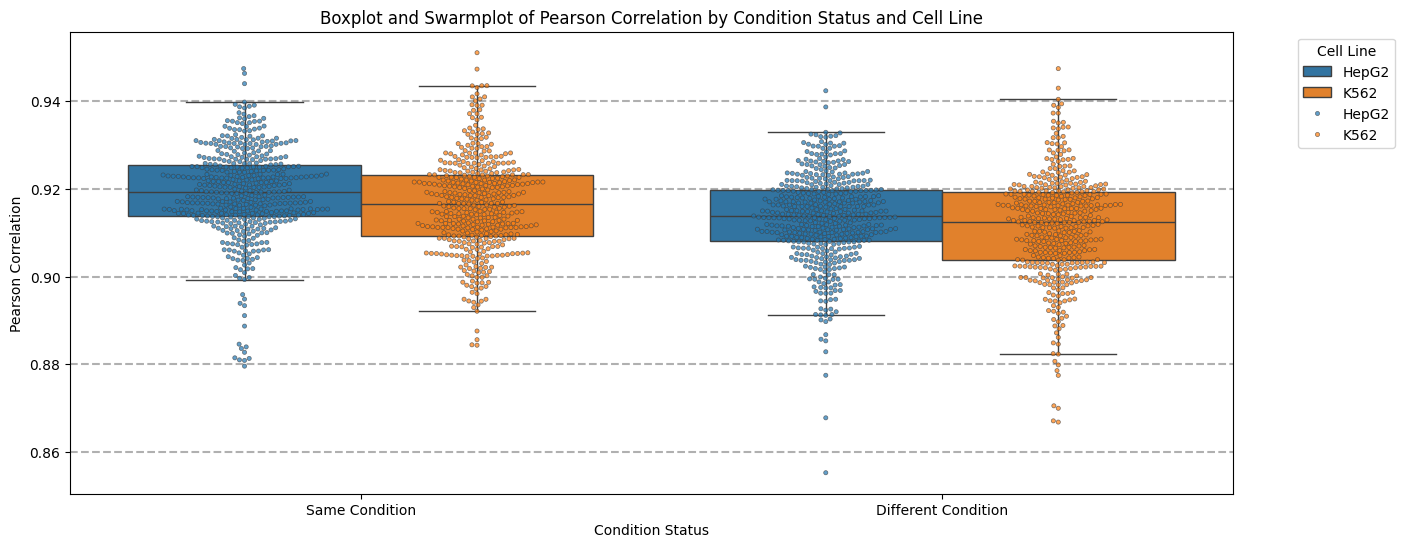

<Figure size 1500x600 with 0 Axes>

<Axes: xlabel='Condition Status', ylabel='Spearman Correlation'>

<Axes: xlabel='Condition Status', ylabel='Spearman Correlation'>

Text(0.5, 1.0, 'Boxplot and Swarmplot of Spearman Correlation by Condition Status and Cell Line')

Text(0.5, 36.72222222222221, 'Condition Status')

Text(132.72222222222223, 0.5, 'Spearman Correlation')

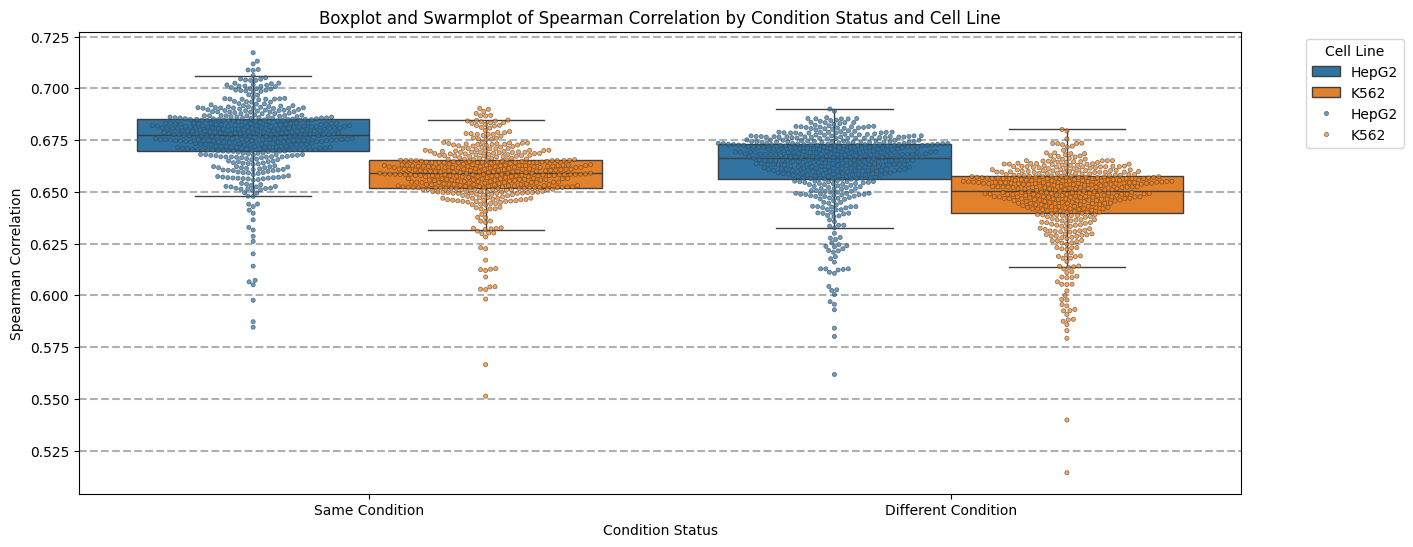

In [14]:
# Create plots for each type of correlation in a loop
for correlation_type in ["Pearson Correlation", "Spearman Correlation"]:
    plt.figure(figsize=(15, 6))
    
    # Create a boxplot
    sns.boxplot(
        data=correlation_df,
        x="Condition Status",
        y=correlation_type,
        hue="Cell Line",
        dodge=True,
        showfliers=False
    )
    
    # Overlay a swarmplot
    sns.swarmplot(
        data=correlation_df,
        x="Condition Status",
        y=correlation_type,
        hue="Cell Line",
        dodge=True,
        alpha=0.7,
        linewidth=0.5, 
        size=3
    )
    
    # Add labels and title
    plt.title(f"Boxplot and Swarmplot of {correlation_type} by Condition Status and Cell Line")
    plt.xlabel("Condition Status")
    plt.ylabel(correlation_type)
    plt.legend(title="Cell Line", bbox_to_anchor=(1.05, 1), loc='upper left')
    
    # Show the plot
    plt.grid(axis='y', which='both', linestyle='--', linewidth=1.5)
    plt.show()
